# CMS Derivatives Pricing Analytics
------------------
> **Idriss Afra**

This project aims to compute CMS convexity adjustments and CMS option values using replication methods, as well as CMS spread option prices.

## The Model Description

CMS (Constant Maturity Swap) derivatives are widely used to gain exposure to long-term interest rates. A CMS payoff depends on a swap rate observed at a future fixing date and paid later on a payment date. We denote this payoff by $f\left(S(T_f, T_0, T_N)\right)$, where:

* $f$ is the payoff function. For example, $f(s)=s$ corresponds to a CMS forward.
* $S(T_f, T_0, T_N)$ is the swap rate fixed at time $T_f$ for the underlying swap running from $T_0$ to $T_N$.
* $T_f \ge 0$ is the fixing date.
* $T_0$ is the start date of the underlying swap, usually $T_0 = T_f + 2BD$.
* $T_N$ is the end date of the underlying swap, so that $T_N-T_0$ is the swap tenor.

Assuming a cash-flow of $f\left(S(T_f, T_0, T_N)\right)$ paid at $T_p  \in [T_0, T_N]$, its present value under the payment measure $Q^{T_p}$ is:

$$
PV = B(0, T_p) \times E^{Q^{T_p}} \left(f\left(S(T_f, T_0, T_N)\right)\right)
$$

Where: $B(0,T_p)$ is the current zero-coupon bond price maturing at $T_p$.

To simplify pricing, we change measure from the $T_p$-forward measure to the level measure (or annuity measure), under which the forward swap rate $S$ is a martingale (i.e., has no drift). 

Define the level process by: $LVL(t,T_0, T_N) = ∑_{1 \le i \le N} \delta_i × B(t, T_i)$, where $(T_i)$ are the fixed-leg payment dates of the underlying swap and $(\delta_i)$ its fixed-leg day count fractions.

Using the Radon-Nikodym change of measure, the present value becomes:   
\begin{equation}
\begin{split}
PV & = B(0, T_p) \times E^{Q^{T_p}} \left( \frac{f\left(S(T_f, T_0, T_N)\right) \times B(T_f, T_p) }{B(T_f, T_p)} \right) \\
& = LVL(0,T_0, T_N) \times E^{Q^{LVL}} \left( \frac{f\left(S(T_f, T_0, T_N)\right) \times B(T_f, T_p) }{LVL(T_f,T_0, T_N)} \right) \\
\end{split}
\end{equation}

---
## The Flat Swap-Curve Approximation

We seek a one-factor approximation of the quantity $\frac{B(T_f, T_p)}{LVL(T_f,T_0, T_N)}$ as a function of the terminal swap rate $S(T_f,T_0,T_N)$, where: 
$$
S(T_f, T_0, T_N) = \frac{B(T_f, T_0) - B(T_f, T_N)}{LVL(T_f,T_0, T_N)}
$$

Rearranging this identity yields:
$$ \frac{B(T_f, T_p)}{LVL(T_f,T_0, T_N)} = \frac{S(T_f, T_0, T_N) \times B(T_f, T_p)}{B(T_f, T_0) - B(T_f, T_N)} = \frac{S(T_f, T_0, T_N) \times \frac{B(T_f, T_p)}{B(T_f, T_0)}}{1 - \frac{B(T_f, T_N)}{B(T_f, T_0)}} $$

Under the Flat Swap-Curve Approximation, we assume that at fixing time $T_f$, the discount factors along the tenor structure of the underlying swap are generated by a flat forward swap curve at level $S(T_f,T_0,T_N)$.
If $m$ denotes the fixed-leg payment frequency, this leads to the approximations:
$$
\frac{B(T_f, T_p)}{B(T_f, T_0)} ≈ \left(1 + \frac{S(T_f, T_0, T_N)}{m}\right)^{-m \times (T_p - T_0)}
\\ \frac{B(T_f, T_N)}{B(T_f, T_0)} ≈ \left(1 + \frac{S(T_f, T_0, T_N)}{m}\right)^{-m \times (T_N - T_0)}
$$

These expressions suggest the functional form:
$$g(s) := \frac{s \times (1 + \frac{s}{m})^{-m \times (T_p - T_0)}}{1 - (1 + \frac{s}{m})^{-m \times (T_N - T_0)}}$$

However, the approximation should also preserve the annuity-measure normalization:
$$E^{Q^{LVL}}\left(\frac{B(T_f, T_p)}{LVL(T_f,T_0, T_N)}\right) = \frac{B(0, T_p)}{LVL(0,T_0, T_N)}$$

To enforce this property, we introduce the normalized function:
$$
g_{norm}(s) := g(s) \times \frac{B(0, T_p)}{LVL(0,T_0, T_N) \times E^{Q^{LVL}}(g\left(S(T_f, T_0, T_N)\right))}
$$

We therefore use the approximation:
$$ 
\frac{B(T_f, T_p)}{LVL(T_f,T_0, T_N)} ≈ g_{norm}\left(S(T_f, T_0, T_N)\right) 
$$

The function $g_{norm}$ is the key ingredient of Hagan’s flat Swap-Curve Approximation. It allows the CMS payoff to be rewritten in terms of a function of the swap rate alone, which is essential for applying static replication techniques such as the Carr-Madan approach.

---
## Application to CMS Forward and Option Pricing

Using Hagan's flat swap-curve approximation, the present value of a CMS-linked payoff can be written as:

\begin{equation}
\begin{split}
PV & = LVL(0,T_0, T_N) \times E^{Q^{LVL}} \left( \frac{f\left(S(T_f, T_0, T_N)\right) \times B(T_f, T_p) }{LVL(T_f,T_0, T_N)} \right) \\
& ≈ LVL(0,T_0, T_N) \times E^{Q^{LVL}} \left[ f(S(T_f, T_0, T_N)) × g_{norm}(S(T_f, T_0, T_N)) \right] \\
& ≈ B(0, T_p) \times \frac{E^{Q^{LVL}} \left[ f(S(T_f, T_0, T_N)) × g(S(T_f, T_0, T_N)) \right]}{E^{Q^{LVL}} \left[ g(S(T_f, T_0, T_N)) \right]} \\
& ≈ B(0, T_p) \times \frac{E^{Q^{LVL}} \left[ h(S(T_f, T_0, T_N)) \right]}{E^{Q^{LVL}} \left[ g(S(T_f, T_0, T_N)) \right]} 
\end{split}
\end{equation}

Where : $h(s) := f(s) \times g(s)$.

This reformulation is the key step: it reduces the CMS pricing problem to the valuation of the expectation of a function of the terminal swap rate under the level measure.

### Carr-Madan Static Replication
To evaluate this expectation, we use the Carr-Madan static replication formula. For any twice differentiable function $w$ and any strike $K^*$:
$$
w(S(T_f, T_0, T_N)) = w(K^*) + w'(K^*) × \left(S(T_f, T_0, T_N) - K^*\right) + ∫_{-∞}^{K^*}w''(k) \times (k-S(T_f, T_0, T_N))^+dk + ∫_{K^*}^{+∞}w''(k) \times (S(T_f, T_0, T_N) - k)^+dk
$$

Taking expectations under the level measure and choosing $K^*=S(0,T_0,T_N)$, the forward swap rate, gives:
$$
E^{Q^{LVL}}\left(S(T_f, T_0, T_N) - K^*\right) = 0
$$

since the forward swap rate is a martingale under $Q^{LVL}$. Therefore:
$$
E^{Q^{LVL}}\left[ w\left(S(T_f, T_0, T_N)\right) \right]  = w(S(0,T_0,T_N)) + ∫_{-∞}^{S(0,T_0,T_N)}w''(k) \times Put_{Swaption}^{OTM}(T_f, k) dk + ∫_{S(0,T_0,T_N)}^{+∞}w''(k) \times Call_{Swaption}^{OTM}(T_f, k) dk
$$

where $Put_{Swaption}^{OTM}(T_f,k)$ and $Call_{Swaption}^{OTM}(T_f,k)$ denote out-of-the-money European swaption forward prices with expiry $T_f$, strike $k$, and tenor of $T_N-T_0$. 

In this project, we use the normal (Bachelier) model to price the European swaptions.

### CMS Forward Price
For a CMS forward, the payoff function is : $f(s) = s$.

So, the replication kernels are: $g$, and $h(s) = s \times g(s)$

The CMS forward is then priced through static replications using out-of-the-money (OTM) swaptions. It differs from the forward swap rate $S(0,T_0,T_N)$ because the swap rate is paid as a single cash flow, rather than through the natural annuity structure of the underlying swap. This induces a convexity adjustment through the measure-change factor $\frac{B(T_f,T_p)}{LVL(T_f,T_0,T_N)}$.

### CMS Caplet Price
For a CMS caplet with strike $K$, the payoff function is: $f(s) = (s - K)^+$.

So, the replication kernels are: $g$, and $h(s) = (s - K)^+  \times g(s)$

For a $C^0$ call-like payoff, the replication formula is adjusted as follows:
$$
\begin{aligned}
E^{Q^{LVL}} \left[ h(S(T_f, T_0, T_N)) \right] = h\left(S(0,T_0,T_N)\right) + g\left(K\right) × \left( 1_{K<S(0, T_0, T_N)} \times Put_{Swaption}(T_f, K) + 1_{K \ge S(0, T_0, T_N)} \times Call_{Swaption}(T_f, K) \right) +
∫_{min(K, S(0, T_0, T_N))}^{S(0, T_0, T_N)}\phi^{''}(k) \times Put_{Swaption}^{OTM}(T_f, k)dk +
∫_{max(K, S(0, T_0, T_N))}^{+∞}\phi^{''}(k) \times Call_{Swaption}^{OTM}(T_f, k)dk 
\end{aligned}
$$

Where: $\phi(s) = (s - K)  \times g(s)$

### CMS Floorlet Price
For a CMS floorlet with strike $K$, the payoff function is: $f(s) = (K - s)^+$.

So, the replication kernels are: $g$, and $h(s) = (K - s)^+  \times g(s)$


For a $C^0$ put-like payoff, the replication formula is adjusted as follows:
$$
\begin{aligned}
E^{Q^{LVL}} \left[ h(S(T_f, T_0, T_N)) \right] = h\left(S(0,T_0,T_N)\right) + g\left(K\right) × \left( 1_{K<S(0, T_0, T_N)} \times Put_{Swaption}(T_f, K) + 1_{K \ge S(0, T_0, T_N)} \times Call_{Swaption}(T_f, K) \right) +
∫_{-∞}^{min(K, S(0, T_0, T_N))}\phi^{''}(k) \times Put_{Swaption}^{OTM}(T_f, k)dk +
∫_{S(0, T_0, T_N)}^{max(K, S(0, T_0, T_N))}\phi^{''}(k) \times Call_{Swaption}^{OTM}(T_f, k)dk
\end{aligned}
$$

Where: $\phi(s) = (K - s)  \times g(s)$

### Numerical Implementation
In this project, the second derivatives appearing in the replication formulas are not computed analytically. Instead, they are approximated numerically using a centred finite-difference scheme with a bump size $\varepsilon = 5 \text{ bp}$.

In addition, the improper integrals over infinite strike ranges are truncated in the numerical implementation. Rather than integrating over $(-\infty, +\infty)$, the integration domain is restricted to a finite interval around the forward swap rate: $\left[F - n \sigma,\; F + n \sigma\right]$, where $F = S(0,T_0,T_N)$ is the forward swap rate, $\sigma$ is the ATM standard deviation, and $n$ is a truncation parameter. By default, this parameter is set to $n = 8$.

---
## Model Implementation

We first define a zero-coupon curve class to construct discounting curves :

In [1]:
import numpy as np
from scipy.interpolate import PchipInterpolator

class ZeroCouponRateCurve:
    """
    Zero-Coupon Rate Curve class.
    """
    def __init__(self, zc_maturities, zc_rates):
        """
        Init method : Takes the IR market tenors and the bootstrapped ZC rates.
        """
        # Sanity checks
        if (not isinstance(zc_maturities, (list, np.ndarray))) or (not isinstance(zc_rates, (list, np.ndarray))):
            raise TypeError(f"ZeroCouponRateCurve : zc_maturities and zc_rates must be lists or arrays.")
        if (len(zc_maturities) != len(zc_rates)):
            raise ValueError(f"ZeroCouponRateCurve : zc_maturities and zc_rates must have the same length.")
        # Store data
        self.zc_maturities = zc_maturities
        self.zc_rates = zc_rates
        self._t0 = zc_maturities[0]
        self._t1 = zc_maturities[-1]
        self._r0 = zc_rates[0]
        self._r1 = zc_rates[-1]
        # Interpolator only valid inside [_t0, _t1]; flat extrpolation outside
        self.zc_rate_interp = PchipInterpolator(zc_maturities, zc_rates, extrapolate=False)

    def zc_rates_interp(self, T):
        """
        Interpolated ZC rate for maturity T.
        T may be a scalar or an array-like.
        """
        T = np.asarray(T)
        r_interp = np.empty_like(T)
        # Below t0, use r0
        r_interp[T < self._t0] = self._r0
        # Above t1, use r1
        r_interp[T > self._t1] = self._r1
        # Between t0 and t1, use PCHIP interpolation
        mask = (T >= self._t0) & (T <= self._t1)
        r_interp[mask] = self.zc_rate_interp(T[mask])
        return r_interp

    def df(self, T):
        """
        Zero-Coupon Discount Factors.
        T may be a scalar or an array-like.
        """
        return np.exp(-self.zc_rates_interp(T)*T)

Then, we implement the swaption instrument class :

In [2]:
from scipy.stats import norm

class EuropeanSwaption:
    """
    European Swaption class under the Normal (Bachelier) model.
    """
    def __init__(self, payer_receiver, expiry, tenor, fixed_leg_accrual=1., start_date_lag=2., notional=1.):
        """
        Init method.
        """
        # Sanity checks
        if (payer_receiver.upper() not in ['PAYER', 'RECEIVER']):
            raise ValueError(f"EuropeanSwaption : payer_receiver must be 'PAYER' or 'RECEIVER'.")
        if (expiry < 0. or tenor <= 0.):
            raise ValueError(f"EuropeanSwaption : expiry must be non-negative and tenor must be positive.")
        if fixed_leg_accrual <= 0:
            raise ValueError("EuropeanSwaption : fixed_leg_accrual must be positive.")
        n = tenor / fixed_leg_accrual
        if not np.isclose(n, round(n)):
            print("EuropeanSwaption Warning : The underlying swap has a short final stub that will be ignored.")
        if n < 1:
            raise ValueError("EuropeanSwaption : tenor must be at least fixed_leg_accrual.")
        # Store data
        self.payer_receiver = payer_receiver.upper()
        self.expiry = expiry
        self.notional = notional
        self.start_time = expiry + start_date_lag / 365. # Simplification: We assume ACT365
        # Fixed leg payment dates (short final stubs are ignored)
        self.pay_times = np.arange(self.start_time + fixed_leg_accrual, self.start_time + tenor + 1e-12, fixed_leg_accrual)
        self.year_fractions = np.array([fixed_leg_accrual] * len(self.pay_times))
        self.is_market_data_set = False

    def is_payer(self):
        return (self.payer_receiver == "PAYER")

    def set_market_data(self, df, normal_vol):
        """
        Stores DFs values to save computation time.
        """
        # Sanity checks
        if not callable(df):
            raise TypeError(f"EuropeanSwaption set_market_data : df must be a callable function.")
        if normal_vol < 0:
            raise ValueError(f"EuropeanSwaption set_market_data : normal_vol must be non-negative.")
        # Store data
        self.df_start_time = df(self.start_time)
        self.df_pay_times = df(self.pay_times)
        self.normal_vol = normal_vol
        self.is_market_data_set = True

    def level(self):
        """
        The level (annuity) function.
        """
        if not self.is_market_data_set:
            raise ValueError(f"EuropeanSwaption level : Market data not set. Call set_market_data() first.")
        return np.sum(self.df_pay_times * self.year_fractions)

    def forward(self):
        """
        The forward swap rate.
        Mono-curve framework : DFs are the same for discounting and forwarding.
        """
        if not self.is_market_data_set:
            raise ValueError(f"EuropeanSwaption forward : Market data not set. Call set_market_data() first.")
        return (self.df_start_time - self.df_pay_times[-1]) / self.level()

    def pv_underlying(self, strike):
        """
        PV of the underlying swap (No optionality).
        Mono-curve framework : DFs are the same for discounting and forwarding.
        """
        if not self.is_market_data_set:
            raise ValueError(f"EuropeanSwaption pv_underlying : Market data not set. Call set_market_data() first.")
        flavor = 1. if self.is_payer() else -1.
        return flavor * self.notional * self.level() * (self.forward() - strike)

    def market_price(self, strike):
        """
        Swaption price under the Normal (Bachelier) model.
        Mono-curve framework : DFs are the same for discounting and forwarding.
        """
        if not self.is_market_data_set:
            raise ValueError(f"EuropeanSwaption market_price : Market data not set. Call set_market_data() first.")
        flavor = 1 if self.is_payer() else -1
        lvl = self.level()
        fwd = self.forward()
        sqrt_V2T = self.normal_vol * np.sqrt(self.expiry)
        if (sqrt_V2T == 0) : return self.notional * lvl * max(flavor * (fwd - strike), 0.)
        d = (fwd - strike) / sqrt_V2T
        return self.notional * lvl * sqrt_V2T * (flavor * d * norm.cdf(flavor * d) + norm.pdf(d))
    
    def market_fwd_price(self, strike):
        """
        Swaption forward price under the Normal (Bachelier) model.
        Mono-curve framework : DFs are the same for discounting and forwarding.
        """
        if not self.is_market_data_set:
            raise ValueError(f"EuropeanSwaption market_fwd_price : Market data not set. Call set_market_data() first.")
        flavor = 1 if self.is_payer() else -1
        fwd = self.forward()
        sqrt_V2T = self.normal_vol * np.sqrt(self.expiry)
        if (sqrt_V2T == 0) : return self.notional * max(flavor * (fwd - strike), 0.)
        d = (fwd - strike) / sqrt_V2T
        return self.notional * sqrt_V2T * (flavor * d * norm.cdf(flavor * d) + norm.pdf(d))

Next, we define a volatility skew class to construct normal vol skews through interpolation and extrapolation methods :

In [3]:
from scipy.interpolate import interp1d

class VolatilitySkewInterpolator:
    """
    Normal Vol Skew.
    """
    def __init__(self, vol_strikes, vol_data, vol_floor=0.0005, vol_cap=1., flat_extrapolation=False):
        """
        Init method : Takes the market strikes and their implied normal volatilities.
        Interpolation is performed with PchipInterpolator, extrapolation is linear.
        Flat extrapolation can be forced through the input flat_extrapolation.
        """
        # Sanity checks
        if (not isinstance(vol_strikes, (list, np.ndarray))) or (not isinstance(vol_data, (list, np.ndarray))):
            raise TypeError(f"VolatilitySkewInterpolator : vol_strikes and vol_data must be lists or arrays.")
        if (len(vol_strikes) != len(vol_data)):
            raise ValueError(f"VolatilitySkewInterpolator : vol_strikes and vol_data must have the same length.")
        vol_strikes, vol_data = np.asarray(vol_strikes, dtype=float), np.asarray(vol_data, dtype=float)
        if not np.all(np.diff(vol_strikes) > 0):
            raise ValueError("VolatilitySkewInterpolator : vol_strikes must be strictly increasing.")
        self.vol_strikes = vol_strikes
        self.vol_data = vol_data
        self.vol_floor = vol_floor
        self.vol_cap = vol_cap
        self.flat_extrapolation = flat_extrapolation
        self._vol_interp = PchipInterpolator(self.vol_strikes, self.vol_data, extrapolate=False)
        self._vol_extrap = interp1d(vol_strikes, vol_data, kind='linear', fill_value="extrapolate")

    def get_vol(self, strike):
        """
        Takes the strike as input, and output the corresponding vol(expiry, strike).
        """
        # Extrapolation
        if strike < self.vol_strikes[0] or strike > self.vol_strikes[-1]:
            if self.flat_extrapolation: 
                return self.vol_data[0] if strike < self.vol_strikes[0] else self.vol_data[-1]
            return min(max(float(self._vol_extrap(strike)), self.vol_floor), self.vol_cap)
        # Interpolation
        return min(max(float(self._vol_interp(strike)), self.vol_floor), self.vol_cap)

Finally, we create the CMS pricer class based on the replication methods to value CMS forwards and options :

In [4]:
from scipy import optimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

class CMSPricer:
    """
    CMS forwards and CMS Caplets / Floorlets pricer, based on replication methods by OTM Swaptions.
    """
    def __init__(self):
        """
        Init method.
        """
        self.is_dates_set = False
        self.is_market_data_set = False

    def set_dates(self, fixing_date, tenor, fixed_leg_accrual=1., start_date_lag=2.):
        """
        Dates setter.
        """
        # Sanity checks
        if (fixing_date < 0. or tenor <= 0.):
            raise ValueError(f"CMSPricer set_dates : fixing_date must be non-negative and tenor must be positive.")
        if fixed_leg_accrual <= 0:
            raise ValueError("CMSPricer set_dates : fixed_leg_accrual must be positive.")
        n = tenor / fixed_leg_accrual
        if not np.isclose(n, round(n)):
            print("CMSPricer set_dates Warning : The underlying swap has a short final stub that will be ignored.")
        if n < 1:
            raise ValueError("CMSPricer set_dates : tenor must be at least fixed_leg_accrual.")
        # Store data
        self.fixing_date = fixing_date
        self.tenor = tenor
        self.fixed_leg_accrual = fixed_leg_accrual
        self.start_date_lag = start_date_lag
        self.start_date = fixing_date + start_date_lag / 365. # Simplification: We assume ACT365
        self.is_dates_set = True

    def set_market_data(self, df, vol_skew):
        """
        Market Data setter.
        vol_skew : Normal swaption skew of expiry self.fixing_date and tenor self.tenor.
        """
        # Sanity checks
        if not callable(df):
            raise TypeError(f"CMSPricer set_market_data : df must be a callable function.")
        if not callable(vol_skew):
            raise TypeError(f"CMSPricer set_market_data : vol_skew must be a callable function.")
        # Store data
        self.df = df
        self.vol_skew = vol_skew
        self.is_market_data_set = True

    def _flat_swp_curve_approx(self, s, pay_date):
        """
        Hagan's flat swap curve approximation method (Unnormalized).
        """
        m = 1. / self.fixed_leg_accrual
        cf = 1 + s / m
        if np.any(np.asarray(cf) <= 0):
            # Extreme case : Large negative swap rate
            raise ValueError("CMSPricer _flat_swp_curve_approx : Flat swap-curve approximation invalid for s <= -m.")
        return s * cf**(-m * (pay_date - self.start_date)) / (1 - cf**(-m * self.tenor))

    def _c2_replication_method(self, payoff_func, pay_date, n_stdev=8., eps=0.0005):
        """
        The replication method of C2-payoff functions.
        """
        # Sanity checks
        if not callable(payoff_func):
            raise TypeError(f"CMSPricer _c2_replication_method : payoff_func must be a callable function.")
        if pay_date < 0.:
            raise ValueError(f"CMSPricer _c2_replication_method : pay_date must be non-negative.")
        if n_stdev <= 0: 
            raise ValueError("CMSPricer _c2_replication_method : n_stdev must be positive.")
        if eps <= 0: 
            raise ValueError("CMSPricer _c2_replication_method : eps must be positive.")
        # adjusted payoff function
        adj_payoff_func = lambda s : payoff_func(s) * self._flat_swp_curve_approx(s, pay_date)
        # Swaption Prices
        payer_swopt = EuropeanSwaption("Payer", self.fixing_date, self.tenor, self.fixed_leg_accrual, self.start_date_lag)
        payer_swopt.set_market_data(self.df, 0.) # Temporary dummy vol value
        receiver_swopt = EuropeanSwaption("Receiver", self.fixing_date, self.tenor, self.fixed_leg_accrual, self.start_date_lag)
        receiver_swopt.set_market_data(self.df, 0.) # Temporary dummy vol value
        def swopt_fwd_price(payer_receiver, k):
            if payer_receiver.upper() == "PAYER":
                payer_swopt.normal_vol = self.vol_skew(k)
                return payer_swopt.market_fwd_price(k)
            else:
                receiver_swopt.normal_vol = self.vol_skew(k)
                return receiver_swopt.market_fwd_price(k)
        # adj_payoff_func 2nd order derivative
        def adj_payoff_func_sd(s, eps=0.0005):
            return (adj_payoff_func(s + eps) + adj_payoff_func(s - eps) - 2 * adj_payoff_func(s)) / (eps**2)
        # Replication method applied on adj_payoff_func
        swp_atm = payer_swopt.forward()
        v2T_atm = self.vol_skew(swp_atm)**2 * self.fixing_date
        lower_bound = swp_atm - n_stdev * np.sqrt(v2T_atm)
        upper_bound = swp_atm + n_stdev * np.sqrt(v2T_atm)
        otm_put_part = lambda k : adj_payoff_func_sd(k, eps) * swopt_fwd_price("Receiver", k)
        otm_call_part = lambda k : adj_payoff_func_sd(k, eps) * swopt_fwd_price("Payer", k)
        fwd_price = adj_payoff_func(swp_atm) + quad(otm_put_part, lower_bound, swp_atm)[0] + quad(otm_call_part, swp_atm, upper_bound)[0]
        return fwd_price

    def _c0_replication_method(self, strike, pay_date, is_call_like, n_stdev=8., eps=0.0005):
        """
        The replication method of C0-payoff functions.
        """
        # Sanity checks
        if pay_date < 0.:
            raise ValueError(f"CMSPricer _c0_replication_method : pay_date must be non-negative.")
        if not isinstance(is_call_like, bool):
            raise TypeError(f"CMSPricer _c0_replication_method : is_call_like must be a boolean.")
        if n_stdev <= 0: 
            raise ValueError("CMSPricer _c0_replication_method : n_stdev must be positive.")
        if eps <= 0: 
            raise ValueError("CMSPricer _c0_replication_method : eps must be positive.")
        # Smooth adjusted payoff function phi
        smooth_payoff_func = lambda s : (s - strike) if is_call_like else (strike - s)
        smooth_adj_payoff_func = lambda s : smooth_payoff_func(s) * self._flat_swp_curve_approx(s, pay_date)
        # Swaption Prices
        payer_swopt = EuropeanSwaption("Payer", self.fixing_date, self.tenor, self.fixed_leg_accrual, self.start_date_lag)
        payer_swopt.set_market_data(self.df, 0.) # Temporary dummy vol value
        receiver_swopt = EuropeanSwaption("Receiver", self.fixing_date, self.tenor, self.fixed_leg_accrual, self.start_date_lag)
        receiver_swopt.set_market_data(self.df, 0.) # Temporary dummy vol value
        def swopt_fwd_price(payer_receiver, k):
            if payer_receiver.upper() == "PAYER":
                payer_swopt.normal_vol = self.vol_skew(k)
                return payer_swopt.market_fwd_price(k)
            else:
                receiver_swopt.normal_vol = self.vol_skew(k)
                return receiver_swopt.market_fwd_price(k)
        # smooth_payoff_func 2nd order derivative
        def smooth_adj_payoff_func_sd(s, eps=0.0005):
            return (smooth_adj_payoff_func(s + eps) + smooth_adj_payoff_func(s - eps) - 2 * smooth_adj_payoff_func(s)) / (eps**2)
        # Replication method applied on max(smooth_payoff_func, 0) x _flat_swp_curve_approx
        swp_atm = payer_swopt.forward()
        v2T_atm = self.vol_skew(swp_atm)**2 * self.fixing_date
        term0 = (max(swp_atm - strike, 0) if is_call_like else max(strike - swp_atm, 0)) * self._flat_swp_curve_approx(swp_atm, pay_date)
        term1 = self._flat_swp_curve_approx(strike, pay_date) * swopt_fwd_price("Payer" if (strike >= swp_atm) else "Receiver", strike)
        lower_bound_put = min(strike, swp_atm) if is_call_like else (swp_atm - n_stdev * np.sqrt(v2T_atm))
        upper_bound_put = swp_atm if is_call_like else min(strike, swp_atm)
        lower_bound_call = max(strike, swp_atm) if is_call_like else swp_atm
        upper_bound_call = (swp_atm + n_stdev * np.sqrt(v2T_atm)) if is_call_like else max(strike, swp_atm)
        otm_put_part = lambda k : smooth_adj_payoff_func_sd(k, eps) * swopt_fwd_price("Receiver", k)
        otm_call_part = lambda k : smooth_adj_payoff_func_sd(k, eps) * swopt_fwd_price("Payer", k)
        fwd_price = term0 + term1 + quad(otm_put_part, lower_bound_put, upper_bound_put)[0] + quad(otm_call_part, lower_bound_call, upper_bound_call)[0]        
        return fwd_price
    
    def get_swap_fwd_rate(self):
        if not self.is_dates_set or not self.is_market_data_set:
            raise ValueError("CMSPricer get_cms_fwd_rate : Required data not set. Call set_dates() and set_market_data() first.")
        payer_swopt = EuropeanSwaption("Payer", self.fixing_date, self.tenor, self.fixed_leg_accrual, self.start_date_lag)
        payer_swopt.set_market_data(self.df, 0.) # Dummy vol value
        return float(payer_swopt.forward())

    def get_cms_fwd_rate(self, pay_date, fwd_price=True, n_stdev=8., eps=0.0005):
        """
        CMS forward rate : swap forward rate + convexity adjustment.
        """
        # Sanity checks
        if not self.is_dates_set or not self.is_market_data_set:
            raise ValueError("CMSPricer get_cms_fwd_rate : Required data not set. Call set_dates() and set_market_data() first.")
        if pay_date < self.start_date:
            raise ValueError("CMSPricer get_cms_fwd_rate : pay_date must be at least start_date.")
        if n_stdev <= 0: 
            raise ValueError("CMSPricer get_cms_fwd_rate : n_stdev must be positive.")
        if eps <= 0: 
            raise ValueError("CMSPricer get_cms_fwd_rate : eps must be positive.")
        # Price
        df_pay_date = 1. if fwd_price else self.df(pay_date)
        return df_pay_date * float(self._c2_replication_method(lambda s: s, pay_date, n_stdev, eps)) / float(self._c2_replication_method(lambda s: 1, pay_date, n_stdev, eps))
    
    def get_cms_option_price(self, strike, pay_date, payer_receiver, fwd_price=True, n_stdev=8., eps=0.0005):
        """
        CMS caplet and floorlet price.
        """
        # Sanity checks
        if not self.is_dates_set or not self.is_market_data_set:
            raise ValueError("CMSPricer get_cms_option_price : Required data not set. Call set_dates() and set_market_data() first.")
        if pay_date < self.start_date:
            raise ValueError("CMSPricer get_cms_option_price : pay_date must be at least start_date.")
        if (payer_receiver.upper() not in ['PAYER', 'RECEIVER']):
            raise ValueError(f"CMSPricer get_cms_option_price : payer_receiver must be 'PAYER' or 'RECEIVER' !")
        if not isinstance(fwd_price, bool):
            raise TypeError(f"CMSPricer get_cms_option_price : fwd_price must be a boolean.")
        if n_stdev <= 0: 
            raise ValueError("CMSPricer get_cms_option_price : n_stdev must be positive.")
        if eps <= 0: 
            raise ValueError("CMSPricer get_cms_option_price : eps must be positive.")
        # Price
        df_pay_date = 1. if fwd_price else self.df(pay_date)
        return df_pay_date * float(self._c0_replication_method(strike, pay_date, payer_receiver.upper()=="PAYER", n_stdev, eps)) / float(self._c2_replication_method(lambda s: 1, pay_date, n_stdev, eps))
    
    def _bachelier_price(self, expiry, fwd, strike, normal_vol, payer_receiver):
        """
        Helper method: Bachelier forward price.
        """
        # Sanity checks
        if expiry < 0: 
            raise ValueError("CMSPricer _bachelier_price : expiry must be non-negative.")
        if (payer_receiver.upper() not in ['PAYER', 'RECEIVER']):
                raise ValueError(f"CMSPricer _bachelier_price : payer_receiver must be 'PAYER' or 'RECEIVER' !")
        if normal_vol < 0: 
                raise ValueError("CMSPricer _bachelier_price : normal_vol must be non-negative.")
        # Bachelier fwd price
        flavor = 1 if (payer_receiver.upper() == 'PAYER') else -1
        sqrt_V2T = normal_vol * np.sqrt(expiry)
        if (sqrt_V2T == 0) : return  max(flavor * (fwd - strike), 0.)
        d = (fwd - strike) / sqrt_V2T
        return sqrt_V2T * (flavor * d * norm.cdf(flavor * d) + norm.pdf(d))
    
    def _bachelier_vega(self, expiry, fwd, strike, normal_vol):
        """
        Helper method: Bachelier forward vega.
        """
        # Sanity checks
        if expiry < 0: 
            raise ValueError("CMSPricer _bachelier_vega : expiry must be non-negative.")
        if normal_vol < 0: 
                raise ValueError("CMSPricer _bachelier_vega : normal_vol must be non-negative.")
        # Bachelier fwd vega
        sqrt_V2T = normal_vol * np.sqrt(expiry)
        if (sqrt_V2T == 0) : return 0.
        d = (fwd - strike) / sqrt_V2T
        return np.sqrt(expiry) * norm.pdf(d)

    def get_cms_normal_vol(self, strike, pay_date, payer_receiver, target_fwd_price, n_stdev=8., eps=0.0005, max_iter=250, tol=1e-8):
        """
        CMS caplet and floorlet implied normal volatility.
        Input target price must be a forward price.
        """
        # Sanity checks
        if not self.is_dates_set or not self.is_market_data_set:
            raise ValueError("CMSPricer get_cms_normal_vol : Required data not set. Call set_dates() and set_market_data() first.")
        if pay_date < self.start_date:
            raise ValueError("CMSPricer get_cms_normal_vol : pay_date must be at least start_date.")
        if (payer_receiver.upper() not in ['PAYER', 'RECEIVER']):
            raise ValueError(f"CMSPricer get_cms_normal_vol : payer_receiver must be 'PAYER' or 'RECEIVER' !")
        if target_fwd_price <= 0: 
            raise ValueError("CMSPricer get_cms_normal_vol : target_fwd_price must be positive.")
        if n_stdev <= 0: 
            raise ValueError("CMSPricer get_cms_normal_vol : n_stdev must be positive.")
        if eps <= 0: 
            raise ValueError("CMSPricer get_cms_normal_vol : eps must be positive.")
        if max_iter < 50: 
            raise ValueError("CMSPricer get_cms_normal_vol : max_iter must be at least 50.")
        if tol <= 0: 
            raise ValueError("CMSPricer get_cms_normal_vol : tol must be positive.")
        # Bachelier parameters
        fwd = self.get_cms_fwd_rate(pay_date, fwd_price=True, n_stdev=n_stdev, eps=eps)
        # Newton-Raphson algorithm
        init_guess = self.vol_skew(strike)
        f = lambda vol : self._bachelier_price(self.fixing_date, fwd, strike, vol, payer_receiver) - target_fwd_price
        f_deriv = lambda vol : self._bachelier_vega(self.fixing_date, fwd, strike, vol)
        try:
            implied_vol, info = optimize.newton(f, init_guess, fprime=f_deriv, maxiter=max_iter, tol=tol, full_output=True)
            if not info.converged:
                print(f"\n CMSPricer get_cms_normal_vol Warning : The NR algorithm failed to derive a volatility for strike {round(strike, 4)} at expiry {round(self.fixing_date, 4)}\n")
                return None
            return float(implied_vol)
        except RuntimeError:
            print(f"\n CMSPricer get_cms_normal_vol : The NR algorithm failed to derive a volatility for strike {round(strike, 4)} at expiry {round(self.fixing_date, 4)}\n")
            return None

    def print_pricing_details(self, pay_date):
        """
        Prints the model outputs: CMS forward, ATM CMS caplet & floorlet prices, CMS volatility, as well as a Call-Put parity validation.
        """
        # Sanity checks
        if pay_date < self.start_date:
            raise ValueError("CMSPricer get_cms_normal_vol : pay_date must be at least start_date.")
        # CMS fwd & ATM options
        if pay_date == self.start_date:
            # CMS In-Advance
            print("CMS In-Advance Pricing Details: ")
            print("--------------------------------")
        elif pay_date == self.start_date + self.tenor:
            # CMS In-Arrears
            print("CMS In-Arrears Pricing Details: ")
            print("--------------------------------")
        else:
            print("CMS Pricing Details: ")
            print("---------------------")
        swp_fwd = self.get_swap_fwd_rate()
        print(f"Forward swap rate (%): {100 * swp_fwd:.4f}")
        cms_fwd = self.get_cms_fwd_rate(pay_date)
        print(f"CMS forward rate (%): {100 * cms_fwd:.4f}")
        print(f"CMS Convexity Adj. (%): {100 * (cms_fwd - swp_fwd):.4f}")
        caplet_fwd_pv = self.get_cms_option_price(cms_fwd, pay_date, "Payer")
        floorlet_fwd_pv = self.get_cms_option_price(cms_fwd, pay_date, "Receiver")
        print(f"ATM CMS Caplet forward price (bp) : {10000. * caplet_fwd_pv:.4f}")
        print(f"ATM CMS Floorlet forward price (bp) : {10000. * floorlet_fwd_pv:.4f}")
        print(f"Parity residual (bp) : {10000. * abs(caplet_fwd_pv - floorlet_fwd_pv):.4f}")
        # Parity residual fwd across a range of strikes
        strikes = np.linspace(swp_fwd - 0.03, swp_fwd + 0.03, 21)
        cms_minus_k = []
        call_minus_put = []
        for strike in strikes:
            cms_caplet = self.get_cms_option_price(strike, pay_date, "PAYER")
            cms_floorlet = self.get_cms_option_price(strike, pay_date, "RECEIVER")
            left_part = cms_caplet - cms_floorlet
            right_part = cms_fwd - strike
            call_minus_put.append(left_part)
            cms_minus_k.append(right_part)
        cms_minus_k = np.array(cms_minus_k)
        call_minus_put = np.array(call_minus_put)
        # Plot parity
        print("\nCMS Put-Call Parity Validation :")
        plt.figure(figsize=(8,5))
        plt.plot(strikes * 100., cms_minus_k * 10000., label="CMS forward - K")
        plt.plot(strikes * 100., call_minus_put * 10000., "--", label="CMS caplet - CMS floorlet")
        plt.xlabel("Strike (%)")
        plt.ylabel("Value (bp)")
        plt.title("CMS Put-Call Parity Across Strikes")
        plt.legend()
        plt.show()
        # CMS Vol across a range of strikes
        moneyness = np.linspace(-0.03, 0.03, 21)
        cms_strikes = cms_fwd + moneyness
        implied_cms_vols = []
        for k_cms in cms_strikes:
            cms_caplet = self.get_cms_option_price(k_cms, pay_date, "PAYER")
            cms_floorlet = self.get_cms_option_price(k_cms, pay_date, "RECEIVER")
            target_price = cms_caplet if k_cms >= cms_fwd else cms_floorlet
            flavor = "PAYER" if k_cms >= cms_fwd else "RECEIVER"
            implied_cms_vol = self.get_cms_normal_vol(k_cms, pay_date, flavor, target_price)
            if implied_cms_vol is None:
                print(f"CMSPricer print_pricing_details Warning : Failed to derive a CMS normal vol for moneyness={k_cms - cms_fwd:.4f}; using the swaption normal vol instead.")
                implied_cms_vols.append(self.vol_skew(swp_fwd + (k_cms - cms_fwd)))
            else:
                implied_cms_vols.append(implied_cms_vol)
        implied_cms_vols = np.array(implied_cms_vols)
        # Plot CMS Vol
        print("CMS Implied Normal Volatility :")
        plt.figure(figsize=(8,5))
        plt.plot(moneyness * 10000., implied_cms_vols * 10000.)
        plt.xlabel("Moneyness (bp)")
        plt.ylabel("Vol (bp)")
        plt.title("CMS Implied Normal Vol")
        plt.show()

---
## Numerical Application

Let us compute $2Y$ and $10Y$ EUR CMS in-advance forwards and options as of February $1$, $2024$, with a $5Y$ expiry and payment at the start date :

### $2Y$ In-Advance CMS:

CMS In-Advance Pricing Details: 
--------------------------------
Forward swap rate (%): 2.5001
CMS forward rate (%): 2.5706
CMS Convexity Adj. (%): 0.0705
ATM CMS Caplet forward price (bp) : 82.2793
ATM CMS Floorlet forward price (bp) : 82.2796
Parity residual (bp) : 0.0003

CMS Put-Call Parity Validation :


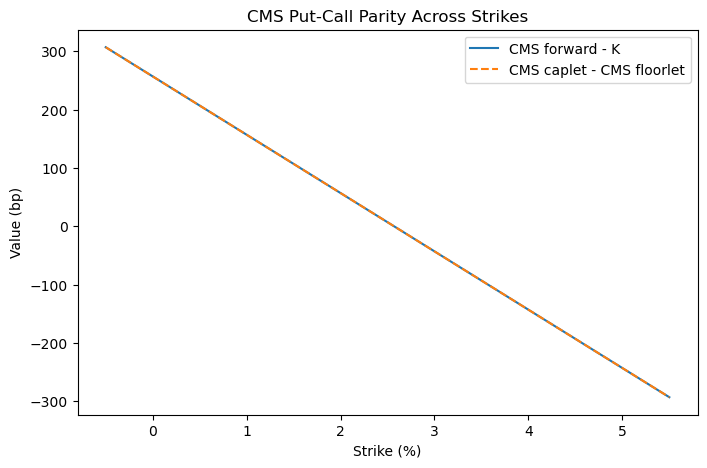

CMS Implied Normal Volatility :


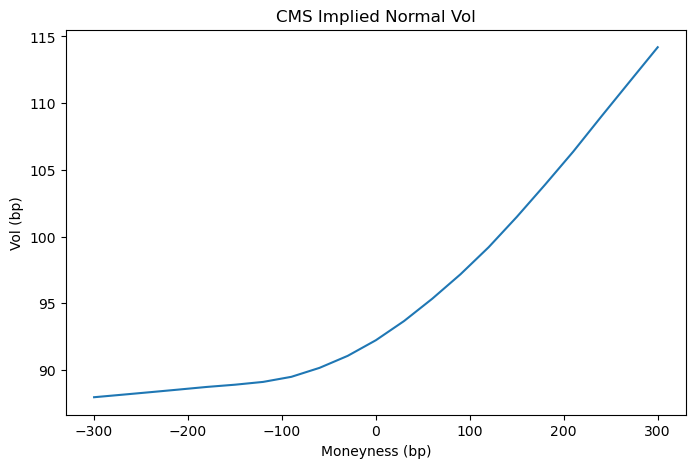

In [5]:
import matplotlib.pyplot as plt

# IR yield curve as of 1st February 2024 (EURIBOR 6M)
zc_maturities = np.array([0.5, 1, 2, 5, 6, 8, 10, 15, 20, 30])
zc_rates = np.array([3.84, 3.41, 2.84, 2.48, 2.47, 2.49, 2.52, 2.6, 2.53, 2.28]) / 100.
yc = ZeroCouponRateCurve(zc_maturities, zc_rates)

# Normal Market Volatilities as of 1st February 2024 (EURIBOR 6M) : Expiry 5Y x Tenor 2Y
expiry = 5.
tenor = 2.
pay_date = 5. + 2./365.
strikes_5y2y = np.array([0.99, 1.49, 1.99, 2.49, 3.49, 4.49, 4.99]) / 100.
normal_vols_5y2y = np.array([88.44, 88.72, 89.62, 91.21, 96.39, 103.72, 107.93]) / 10000.
vol_skew_5y2y = VolatilitySkewInterpolator(strikes_5y2y, normal_vols_5y2y)

# 5Yx2Y CMS paid in-advance
cms_pricer_5y2y = CMSPricer()
cms_pricer_5y2y.set_dates(expiry, tenor)
cms_pricer_5y2y.set_market_data(yc.df, vol_skew_5y2y.get_vol)
cms_pricer_5y2y.print_pricing_details(cms_pricer_5y2y.start_date)


### $10Y$ In-Advance CMS:

CMS In-Advance Pricing Details: 
--------------------------------
Forward swap rate (%): 2.6875
CMS forward rate (%): 2.9184
CMS Convexity Adj. (%): 0.2309
ATM CMS Caplet forward price (bp) : 78.4024
ATM CMS Floorlet forward price (bp) : 78.4024
Parity residual (bp) : 0.0000

CMS Put-Call Parity Validation :


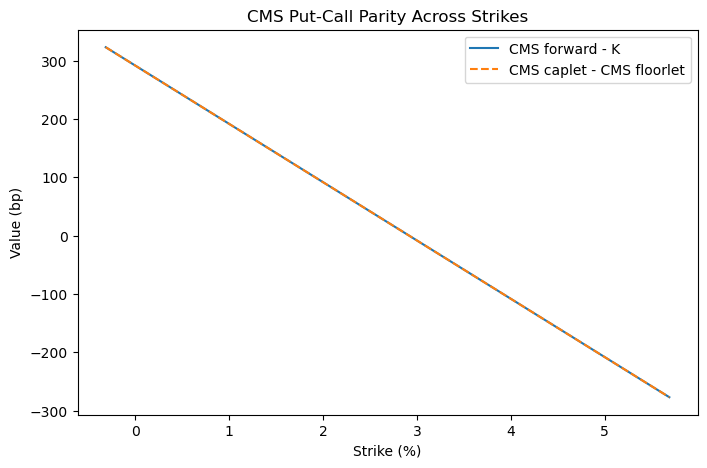

CMS Implied Normal Volatility :


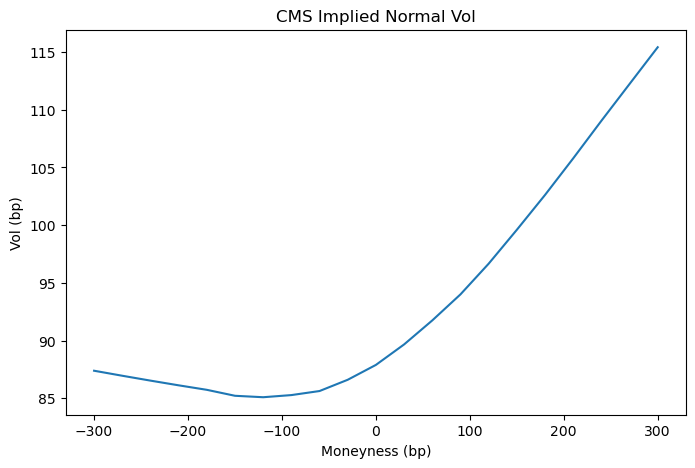

In [6]:
import matplotlib.pyplot as plt

# IR yield curve as of 1st February 2024 (EURIBOR 6M)
zc_maturities = np.array([0.5, 1, 2, 5, 6, 8, 10, 15, 20, 30])
zc_rates = np.array([3.84, 3.41, 2.84, 2.48, 2.47, 2.49, 2.52, 2.6, 2.53, 2.28]) / 100.
yc = ZeroCouponRateCurve(zc_maturities, zc_rates)

# Normal Market Volatilities as of 1st February 2024 (EURIBOR 6M) : Expiry 5Y x Tenor 10Y
expiry = 5.
tenor = 10.
pay_date = 5. + 2./365.
strikes_5y10y = np.array([1.18, 1.68, 2.18, 2.68, 3.68, 4.68, 5.18]) / 100.
normal_vols_5y10y = np.array([84.70, 83.81, 83.76, 84.74, 89.82, 98.07, 102.91]) / 10000.
vol_skew_5y10y = VolatilitySkewInterpolator(strikes_5y10y, normal_vols_5y10y)

# 5Yx10Y CMS paid in-advance
cms_pricer_5y10y = CMSPricer()
cms_pricer_5y10y.set_dates(expiry, tenor)
cms_pricer_5y10y.set_market_data(yc.df, vol_skew_5y10y.get_vol)
cms_pricer_5y10y.print_pricing_details(cms_pricer_5y10y.start_date)


---
## Application to CMS Spread Option Pricing

CMS spread derivatives are structured products whose payoff depends on the difference between two swap rates of different maturities. They are commonly used to express views on changes in the slope or shape of the yield curve.

Consider a CMS spread caplet (the floorlet case is analogous) paying $\max\left(S^1(T_f,T_0,T_1) - S^2(T_f,T_0,T_2) -K; 0\right)$ at $T_p$, where :

* $T_f \ge 0$ is the fixing date, at which both swap rates are observed.
* $S^1(T_f,T_0,T_1)$ is the swap rate fixed at $T_f$ for the underlying swap running from $T_0$ to $T_1$.
* $S^2(T_f,T_0,T_2)$ is the swap rate fixed at $T_f$ for the underlying swap running from $T_0$ to $T_2$.
* $K$ is the strike spread.

The present value of this caplet under the $T_p$-forward measure $Q^{T_p}$ is :    

$$
PV = B(0,T_p) \times E^{Q^{T_p}} \left( \max\left(S^1(T_f,T_0,T_1) - S^2(T_f,T_0,T_2) -K; 0\right) \right)
$$

Where :

* $B(0,T_p)$ is the zero-coupon bond price maturing at $T_p$.

Using the CMS forward rates associated with payment date $T_p$, we define:
$$
CMS^1(t) := E_t^{Q^{T_p}}\left[S^1(T_f,T_0,T_1)\right]
\\ CMS^2(t) := E_t^{Q^{T_p}}\left[S^2(T_f,T_0,T_2)\right]
$$

The CMS spread option is then approximated as an option on the difference between these two CMS forwards.

We model the two CMS forwards under the $T_p$-forward measure with correlated normal (Bachelier) dynamics:
$$
CMS^1(t) = CMS^1(0) + \sigma_1.W^{Q^{T_p}}_1(t)
\\ CMS^2(t) = CMS^2(0) + \sigma_2.W^{Q^{T_p}}_2(t)
\\ d<W^{Q^{T_p}}_1, W^{Q^{T_p}}_2>_t = \rho_{1,2}.dt
$$

Where : $\left(W^{Q^{T_p}}_1, W^{Q^{T_p}}_2\right)$ are two $\rho_{1,2}$-correlated standard Brownian motions. 

We assume that $\sigma_1$ and $\sigma_2$ are the ATM normal implied volatilities of the two CMS rates, obtained by inverting the Bachelier formula from the corresponding ATM CMS caplet prices, with strike equal to the CMS forward $CMS(0)$:
$$
E^{Q^{T_p}}\left[\left(CMS(T_f)-CMS(0)\right)^+\right].
$$

Therefore :
$$
CMS^1(t) - CMS^2(t) = CMS^1(0) - CMS^2(0) + \sigma_1.W^{Q^{T_p}}_1(t) - \sigma_2.W^{Q^{T_p}}_2(t)
$$

Hence :
$$
CMS^1(t) - CMS^2(t) = CMS^1(0) - CMS^2(0) + \sigma_{1,2}.W^{Q^{T_p}}(t)
$$

Where: $W^{Q^{T_p}}$ is a standard Brownian motion, and
$$
\sigma_{1,2}=\sqrt{\sigma_1^2 + \sigma_2^2 - 2\rho_{1,2}\sigma_1\sigma_2}
$$

Finally, the CMS spread caplet price is approximated by the Bachelier formula :
$$
PV = B(0,T_p) \times Bachelier\left( Expiry=T_f; Forward=CMS^1(0) - CMS^2(0); Strike=K; Vol=\sigma_{1,2} \right)
$$

The correlation parameter $\rho_{1,2}$ can either be calibrated from market CMS spread option quotes or, if such quotes are unavailable, estimated from historical swap-rate time series.

Although more advanced methods exist, such as replication approaches coupled with copula-based dependence modeling, the present approximation is often preferred in practice for its simplicity, low computational cost, and effectiveness as a first-order pricing tool.

We price the in-advance ATM spread caplet across a range of correlation assumptions:

In [7]:
class CMSSpreadPricer:
    """
    CMS Spread Caplets / Floorlets normal (Bachelier) pricer.
    """
    def __init__(self, cms_pricer_1, cms_pricer_2):
        """
        Init method.
        """
        if (not isinstance(cms_pricer_1, CMSPricer)) or (not isinstance(cms_pricer_2, CMSPricer)):
            raise TypeError(f"CMSSpreadPricer : cms_pricer_1 and cms_pricer_2 must be instances of the CMSPricer class.")
        if cms_pricer_1.fixing_date != cms_pricer_2.fixing_date:
            raise ValueError(f"CMSSpreadPricer : cms_pricer_1 and cms_pricer_2 must have the same expiries (fixing date).")
        self.cms_pricer_1 = cms_pricer_1
        self.cms_pricer_2 = cms_pricer_2

    def _bachelier_price(self, expiry, fwd, strike, normal_vol, payer_receiver):
        """
        Helper method: Bachelier forward price.
        """
        if expiry < 0: 
            raise ValueError("CMSSpreadPricer _bachelier_price : expiry must be non-negative.")
        if (payer_receiver.upper() not in ['PAYER', 'RECEIVER']):
                raise ValueError(f"CMSSpreadPricer _bachelier_price : payer_receiver must be 'PAYER' or 'RECEIVER' !")
        if normal_vol < 0: 
                raise ValueError("CMSSpreadPricer _bachelier_price : normal_vol must be non-negative.")
        flavor = 1 if (payer_receiver.upper() == 'PAYER') else -1
        sqrt_V2T = normal_vol * np.sqrt(expiry)
        if (sqrt_V2T == 0) : return  max(flavor * (fwd - strike), 0.)
        d = (fwd - strike) / sqrt_V2T
        return sqrt_V2T * (flavor * d * norm.cdf(flavor * d) + norm.pdf(d))
    
    def get_cms_spread_forward_rate(self, pay_date):
        """
        Returns the CMS spread forward rate.
        """
        cms_fwd_1 = self.cms_pricer_1.get_cms_fwd_rate(pay_date)
        cms_fwd_2 = self.cms_pricer_2.get_cms_fwd_rate(pay_date)
        return cms_fwd_1 - cms_fwd_2

    def get_cms_spread_option_price(self, strike, pay_date, payer_receiver, corr, fwd_price=True):
        """
        CMS spread caplet and floorlet forward price.
        """
        if (payer_receiver.upper() not in ['PAYER', 'RECEIVER']):
            raise ValueError(f"CMSSpreadPricer _bachelier_price : payer_receiver must be 'PAYER' or 'RECEIVER' !")
        if corr < -1 or corr > 1: 
            raise ValueError("CMSSpreadPricer get_cms_spread_option_price : corr must be within -1 and 1.")
        expiry = self.cms_pricer_1.fixing_date
        cms_fwd_1 = self.cms_pricer_1.get_cms_fwd_rate(pay_date)
        target_fwd_price_1 = self.cms_pricer_1.get_cms_option_price(cms_fwd_1, pay_date, payer_receiver)
        cms_atm_vol_1 = self.cms_pricer_1.get_cms_normal_vol(cms_fwd_1, pay_date, payer_receiver, target_fwd_price_1)
        cms_fwd_2 = self.cms_pricer_2.get_cms_fwd_rate(pay_date)
        target_fwd_price_2 = self.cms_pricer_2.get_cms_option_price(cms_fwd_2, pay_date, payer_receiver)
        cms_atm_vol_2 = self.cms_pricer_2.get_cms_normal_vol(cms_fwd_2, pay_date, payer_receiver, target_fwd_price_2)
        cms_spread_atm_vol = float(np.sqrt(cms_atm_vol_1**2 + cms_atm_vol_2**2 - 2 * cms_atm_vol_1 * cms_atm_vol_2 * corr))
        df_pay_date = 1. if fwd_price else self.cms_pricer_1.df(pay_date)
        return df_pay_date * self._bachelier_price(expiry, cms_fwd_1 - cms_fwd_2, strike, cms_spread_atm_vol, payer_receiver)
    
    def get_implied_cms_corr(self, strike, pay_date, payer_receiver, target_fwd_price, max_iter=250, tol=1e-8):
        """
        CMS spread implied correlation.
        Input target price must be a forward price.
        """
        if (payer_receiver.upper() not in ['PAYER', 'RECEIVER']):
            raise ValueError(f"CMSSpreadPricer _bachelier_price : payer_receiver must be 'PAYER' or 'RECEIVER' !")
        if target_fwd_price <= 0: 
            raise ValueError("CMSPricer get_cms_normal_vol : target_fwd_price must be positive.")
        expiry = self.cms_pricer_1.fixing_date
        f = lambda corr: self.get_cms_spread_option_price(strike, pay_date, payer_receiver, corr) - target_fwd_price
        f_min = f(-1.00)
        f_max = f(1.00)
        if f_min * f_max > 0:
            print(f"CMSSpreadPricer get_implied_cms_corr : target_fwd_price is outside the attainable price range for strike {round(strike, 4)} at expiry {round(expiry, 4)}\n")
            return None
        try:
            implied_corr = optimize.brentq(f, -1.00, 1.00, xtol=tol, maxiter=max_iter)
            return float(implied_corr)
        except ValueError:
            print(f"CMSSpreadPricer get_implied_cms_corr : The brentq algorithm failed to derive a correlation for strike {round(strike, 4)} at expiry {round(expiry, 4)}\n")
            return None

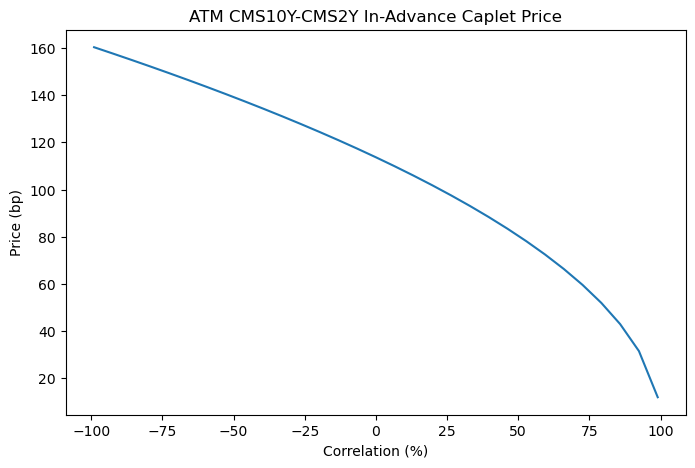

In [8]:
# ATM CMS10Y-CMS2Y In-Advance Caplet Prices
cms_spread_pricer_10y_2y = CMSSpreadPricer(cms_pricer_5y10y, cms_pricer_5y2y)
cms_spread_forward = cms_spread_pricer_10y_2y.get_cms_spread_forward_rate(cms_pricer_5y10y.start_date)
corrs = np.linspace(-0.99, 0.99, 31)
cms_spread_prices_10y_2y = []
for corr in corrs:
    cms_spread_prices_10y_2y.append(cms_spread_pricer_10y_2y.get_cms_spread_option_price(cms_spread_forward, cms_pricer_5y10y.start_date, "Payer", corr))
cms_spread_prices_10y_2y = np.array(cms_spread_prices_10y_2y)
# Plot 
plt.figure(figsize=(8,5))
plt.plot(corrs * 100., cms_spread_prices_10y_2y * 10000.)
plt.xlabel("Correlation (%)")
plt.ylabel("Price (bp)")
plt.title("ATM CMS10Y-CMS2Y In-Advance Caplet Price")
plt.show()

The ATM $CMS10Y–CMS2Y$ caplet price decreases as correlation increases, since a higher positive correlation reduces the volatility of the spread $(CMS10Y - CMS2Y)$. 

The concave shape reflects the normal spread-volatility approximation $\sigma_{1,2}=\sqrt{\sigma_1^2 + \sigma_2^2 - 2\rho_{1,2}\sigma_1\sigma_2}$,
under which the ATM Bachelier caplet price is approximately proportional to the spread volatility. Hence, negative correlation produces the highest option values, while prices fall sharply as correlation approaches $+1$.